#  **Part# 01 Data curation and Preprocessing**

Mudasir Alvi

In this first notebook we will download the ChEMBL Bioactivity for **Sigma-1 receptor (S1R)**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# adjust if your folder is deeper
os.chdir("/content/drive/MyDrive/QSAR_Sigma1R/NoteBooks")

print("Now working in:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls


CDD_part#01_Download_Data.ipynb  Untitled0.ipynb


##  **ChEMBL Database**

ChEMBL is a large-scale, open-access bioactivity database manually curated by the European Bioinformatics Institute (EBI) at the European Molecular Biology Laboratory (EMBL). It contains bioactivity data for over 2.5 million unique compounds.

-  **Data Source:** The data is extracted manually from the scientific literature (over 100,000 publications) and also includes data from patent applications and other internal sources. For each compound-target interaction, it stores quantitative data such as:

-  IC₅₀ (Half-maximal inhibitory concentration)

-  Ki (Inhibition constant)

-  EC₅₀ (Half-maximal effective concentration)

-  Kd (Dissociation constant)

A major strength is its manual curation, which ensures data is standardized, annotated with confidence flags, and linked to original sources. Making it highly reliable for computational modeling like QSAR.

##  **Installing Libraries**

Install ChEMBL Web services package so we can directly retrive te dataset of bioactivity data.

In [ ]:
!pip install chembl_webresource_client

In [ ]:
!pip install tree


##  **Import Libraries**

In [ ]:
# import necessary libraries
import pandas as pd
from chembl_webresource_client.new_client import new_client

## **Search for Target Protein**

Our target of interest is **Sigma non-opioid intracellular receptor 1**. Other names for the target proteins are:
-  Aging-associated gene 8 protein
-  hSigmaR1
-  OPRS1
-  SIG-1R
-  Sigma 1-type opioid receptor
-  Sigma1-receptor
-  Sigma1R
-  SR-BP
-  SR31747-binding protein
-  SRBP




In [ ]:
# Target search for Neurodegenerative and neurodiseases
target = new_client.target
target_query = target.search('Sigma non-opioid intracellular receptor 1')
targets = pd.DataFrame.from_dict(target_query)
targets


,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Mus musculus,Sigma opioid receptor,55.0,False,CHEMBL3465,"[{'accession': 'O55242', 'component_descriptio...",SINGLE PROTEIN,10090.0
1,[],Rattus norvegicus,Sigma opioid receptor,55.0,False,CHEMBL3602,"[{'accession': 'Q9R0C9', 'component_descriptio...",SINGLE PROTEIN,10116.0
2,[],Cavia porcellus,Sigma-1 receptor,52.0,False,CHEMBL4153,"[{'accession': 'Q60492', 'component_descriptio...",SINGLE PROTEIN,10141.0
3,[],Homo sapiens,Sigma opioid receptor,46.0,False,CHEMBL287,"[{'accession': 'Q99720', 'component_descriptio...",SINGLE PROTEIN,9606.0
4,[],Homo sapiens,Sigma receptor,45.0,False,CHEMBL4524009,"[{'accession': 'Q99720', 'component_descriptio...",PROTEIN FAMILY,9606.0
...,...,...,...,...,...,...,...,...,...
5791,[],Mus musculus,Histone deacetylase,0.0,False,CHEMBL3832944,"[{'accession': 'Q8VH37', 'component_descriptio...",PROTEIN FAMILY,10090.0
5792,[],Escherichia coli,Beta-lactamase,0.0,False,CHEMBL3885665,"[{'accession': 'Q53TY8', 'component_descriptio...",SINGLE PROTEIN,562.0
5793,[],Acinetobacter baumannii,Beta-lactamase OXA-23,0.0,False,CHEMBL3885669,"[{'accession': 'Q9L4P2', 'component_descriptio...",SINGLE PROTEIN,470.0
5794,[],Homo sapiens,DNA-PK/Ku70/Ku85,0.0,False,CHEMBL4106136,"[{'accession': 'P78527', 'component_descriptio...",PROTEIN COMPLEX,9606.0


##  **Asgin and Retrive data for Human SIR**

4th entery in the dataframe.

In [ ]:
selected_target = targets.target_chembl_id[3]
selected_target

'CHEMBL287'

Here, we retrive the bioactivity data for human SIR (CHEMBL287).

In [ ]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [ ]:
df = pd.DataFrame.from_dict(res)
df

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33306,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,72.0
1,None,None,34563,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,6.0
2,None,None,46551,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,9.0
3,None,None,51708,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,16.0
4,None,None,53078,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,"{'action_type': 'INHIBITOR', 'description': 'N...",None,22409313,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL4671153,Displacement of [3H]-Pentazocine from human re...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,3.5
1904,"{'action_type': 'AGONIST', 'description': 'Bin...",None,22850774,[],CHEMBL4723516,Binding affinity to sigma-1 receptor (unknown ...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.86
1905,"{'action_type': 'AGONIST', 'description': 'Bin...",None,24977774,[],CHEMBL5225125,Binding affinity to sigma 1 receptor (unknown ...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.86
1906,"{'action_type': 'ANTAGONIST', 'description': '...",None,25473513,[],CHEMBL5325666,Antagonist activity at sigma 1 receptor (unkno...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.084


In [ ]:
!pwd


/content/drive/MyDrive/QSAR_Sigma1R/NoteBooks


In [ ]:
!tree ../


/bin/bash: line 1: tree: command not found


Save SIR Bioactivity Data as csv.

In [ ]:
df.to_csv('../Data/SIR_bioactivity_data_01.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1908 entries, 0 to 1907
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                5 non-null      object 
 1   activity_comment           844 non-null    object 
 2   activity_id                1908 non-null   int64  
 3   activity_properties        1908 non-null   object 
 4   assay_chembl_id            1908 non-null   object 
 5   assay_description          1908 non-null   object 
 6   assay_type                 1908 non-null   object 
 7   assay_variant_accession    0 non-null      object 
 8   assay_variant_mutation     0 non-null      object 
 9   bao_endpoint               1908 non-null   object 
 10  bao_format                 1908 non-null   object 
 11  bao_label                  1908 non-null   object 
 12  canonical_smiles           1875 non-null   object 
 13  data_validity_comment      0 non-null      objec

##  **Handle Missing Data**



We have to drop the ligands which miss the **standard_value** and the **canonical_smiles**

In [ ]:
df2 = df[df.standard_value.notna()]
df2 = df2[df.canonical_smiles.notna()]
df2

/tmp/ipython-input-3852201246.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[df.canonical_smiles.notna()]


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33306,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,72.0
1,None,None,34563,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,6.0
2,None,None,46551,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,9.0
3,None,None,51708,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,16.0
4,None,None,53078,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,"{'action_type': 'INHIBITOR', 'description': 'N...",None,22409313,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL4671153,Displacement of [3H]-Pentazocine from human re...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,3.5
1904,"{'action_type': 'AGONIST', 'description': 'Bin...",None,22850774,[],CHEMBL4723516,Binding affinity to sigma-1 receptor (unknown ...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.86
1905,"{'action_type': 'AGONIST', 'description': 'Bin...",None,24977774,[],CHEMBL5225125,Binding affinity to sigma 1 receptor (unknown ...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.86
1906,"{'action_type': 'ANTAGONIST', 'description': '...",None,25473513,[],CHEMBL5325666,Antagonist activity at sigma 1 receptor (unkno...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.084


In [ ]:
# total unique ligands based on canonical smiles

len(df2.canonical_smiles.unique())

779

In [ ]:
# drop duplicates based on the canonical smiles

df2_unique = df2.drop_duplicates(['canonical_smiles'])
df2_unique

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33306,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,72.0
1,None,None,34563,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,6.0
2,None,None,46551,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,9.0
3,None,None,51708,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,16.0
4,None,None,53078,[],CHEMBL804884,The compound was evaluated for binding affinit...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902,None,None,19128537,[],CHEMBL4374382,Displacement of [3H]PPP from sigma1 receptor (...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,nM,UO_0000065,None,354.0
1903,"{'action_type': 'INHIBITOR', 'description': 'N...",None,22409313,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL4671153,Displacement of [3H]-Pentazocine from human re...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,3.5
1904,"{'action_type': 'AGONIST', 'description': 'Bin...",None,22850774,[],CHEMBL4723516,Binding affinity to sigma-1 receptor (unknown ...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.86
1906,"{'action_type': 'ANTAGONIST', 'description': '...",None,25473513,[],CHEMBL5325666,Antagonist activity at sigma 1 receptor (unkno...,B,None,None,BAO_0000190,...,Homo sapiens,Sigma opioid receptor,9606,None,None,IC50,uM,UO_0000065,None,0.084


## **Preprocess the Bioactivity Data**

Here, we will select the columns we need for futher modeling. we combine three columns , molecule_chembl_id, canonical_smiles , standard_type

In [ ]:
selected_columns = ['molecule_chembl_id','canonical_smiles','standard_value']
df3 = df2_unique[selected_columns]
df3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL67010,C/C(=N\C1CCCCC1)NC12CC3CC(CC(C3)C1)C2,72.0
1,CHEMBL542638,C/C(=N\C12CC3CC(CC(C3)C1)C2)Nc1ccccc1C.Cl,6.0
2,CHEMBL544054,C/C(=N\C1CCCCC1)Nc1ccccc1C.Cl,9.0
3,CHEMBL67388,C/C(=N\C12CC3CC(CC(C3)C1)C2)NC12CC3CC(CC(C3)C1)C2,16.0
4,CHEMBL538754,C/C(=N\c1ccccc1C)Nc1ccccc1C.Cl,15.0
...,...,...,...
1902,CHEMBL596,CCC(=O)N(c1ccccc1)C1CCN(CCc2ccccc2)CC1,354.0
1903,CHEMBL4761695,[2H]C([2H])([2H])Oc1cc(F)cc2c(N3CCN(c4ccccc4F)...,3500.0
1904,CHEMBL4297224,CN(C)CC1CCOC1(c1ccccc1)c1ccccc1,860.0
1906,CHEMBL4519018,CN1C2CCCC1CC(Nc1ccccc1Br)C2,84.0


save preprocessed data

In [ ]:
df3.to_csv('../Data/SIR_preprocessed_02_data.csv', index=False)

**Add pIC 50 values column**

In [ ]:
import numpy as np

# Copy dataframe to avoid modifying original
df4 = df3.copy()

# Convert standard_value to numeric, coercing errors to NaN
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors='coerce')

# Drop rows where standard_value is NaN after coercion
df4 = df4[df4["standard_value"].notna()]

# Convert IC50 (nM) to molar units (M)
# IC50 in ChEMBL is usually in nM, so 1 nM = 1e-9 M
df4["standard_value_M"] = df4["standard_value"] * 1e-9

# Calculate pIC50 = -log10(IC50 [M])
df4["pIC50"] = -np.log10(df4["standard_value_M"])

# Drop rows where conversion failed (e.g., negative or zero IC50)
df4 = df4[df4["standard_value_M"] > 0]

# Show head of updated dataframe
display(df4.head())

,molecule_chembl_id,canonical_smiles,standard_value,standard_value_M,pIC50
0,CHEMBL67010,C/C(=N\C1CCCCC1)NC12CC3CC(CC(C3)C1)C2,72.0,7.200000e-08,7.142668
1,CHEMBL542638,C/C(=N\C12CC3CC(CC(C3)C1)C2)Nc1ccccc1C.Cl,6.0,6.000000e-09,8.221849
2,CHEMBL544054,C/C(=N\C1CCCCC1)Nc1ccccc1C.Cl,9.0,9.000000e-09,8.045757
3,CHEMBL67388,C/C(=N\C12CC3CC(CC(C3)C1)C2)NC12CC3CC(CC(C3)C1)C2,16.0,1.600000e-08,7.795880
4,CHEMBL538754,C/C(=N\c1ccccc1C)Nc1ccccc1C.Cl,15.0,1.500000e-08,7.823909


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779 entries, 0 to 1907
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  779 non-null    object 
 1   canonical_smiles    779 non-null    object 
 2   standard_value      779 non-null    float64
 3   standard_value_M    779 non-null    float64
 4   pIC50               779 non-null    float64
dtypes: float64(3), object(2)
memory usage: 36.5+ KB


In [ ]:
# save the updated dataframe with pIc50

df4.to_csv('../Data/SIR_bioactivity_data_pIC50_03.csv', index=False)

##  **Summary Statistics**

In [ ]:
# Load the saved dataset
import pandas as pd

df = pd.read_csv("../Data/SIR_bioactivity_data_pIC50_03.csv")

# Summary statistics for pIC50
summary_stats = df["pIC50"].describe()

# Count unique ligands
unique_ligands = df["molecule_chembl_id"].nunique()

print("📊 Summary of Sigma-1R Bioactivity Data")
print("=====================================")
print(f"Total ligands (unique): {unique_ligands}")
print(summary_stats)

# Display as a nice table
import matplotlib.pyplot as plt

summary_table = pd.DataFrame(summary_stats)
summary_table.columns = ["pIC50 Stats"]
print("\nFormatted Table:")
print(summary_table)


📊 Summary of Sigma-1R Bioactivity Data
Total ligands (unique): 779
count    779.000000
mean       6.918596
std        1.071030
min        4.000000
25%        6.223696
50%        6.962574
75%        7.672855
max        9.599980
Name: pIC50, dtype: float64

Formatted Table:
       pIC50 Stats
count   779.000000
mean      6.918596
std       1.071030
min       4.000000
25%       6.223696
50%       6.962574
75%       7.672855
max       9.599980


**pIC50 Distribution**

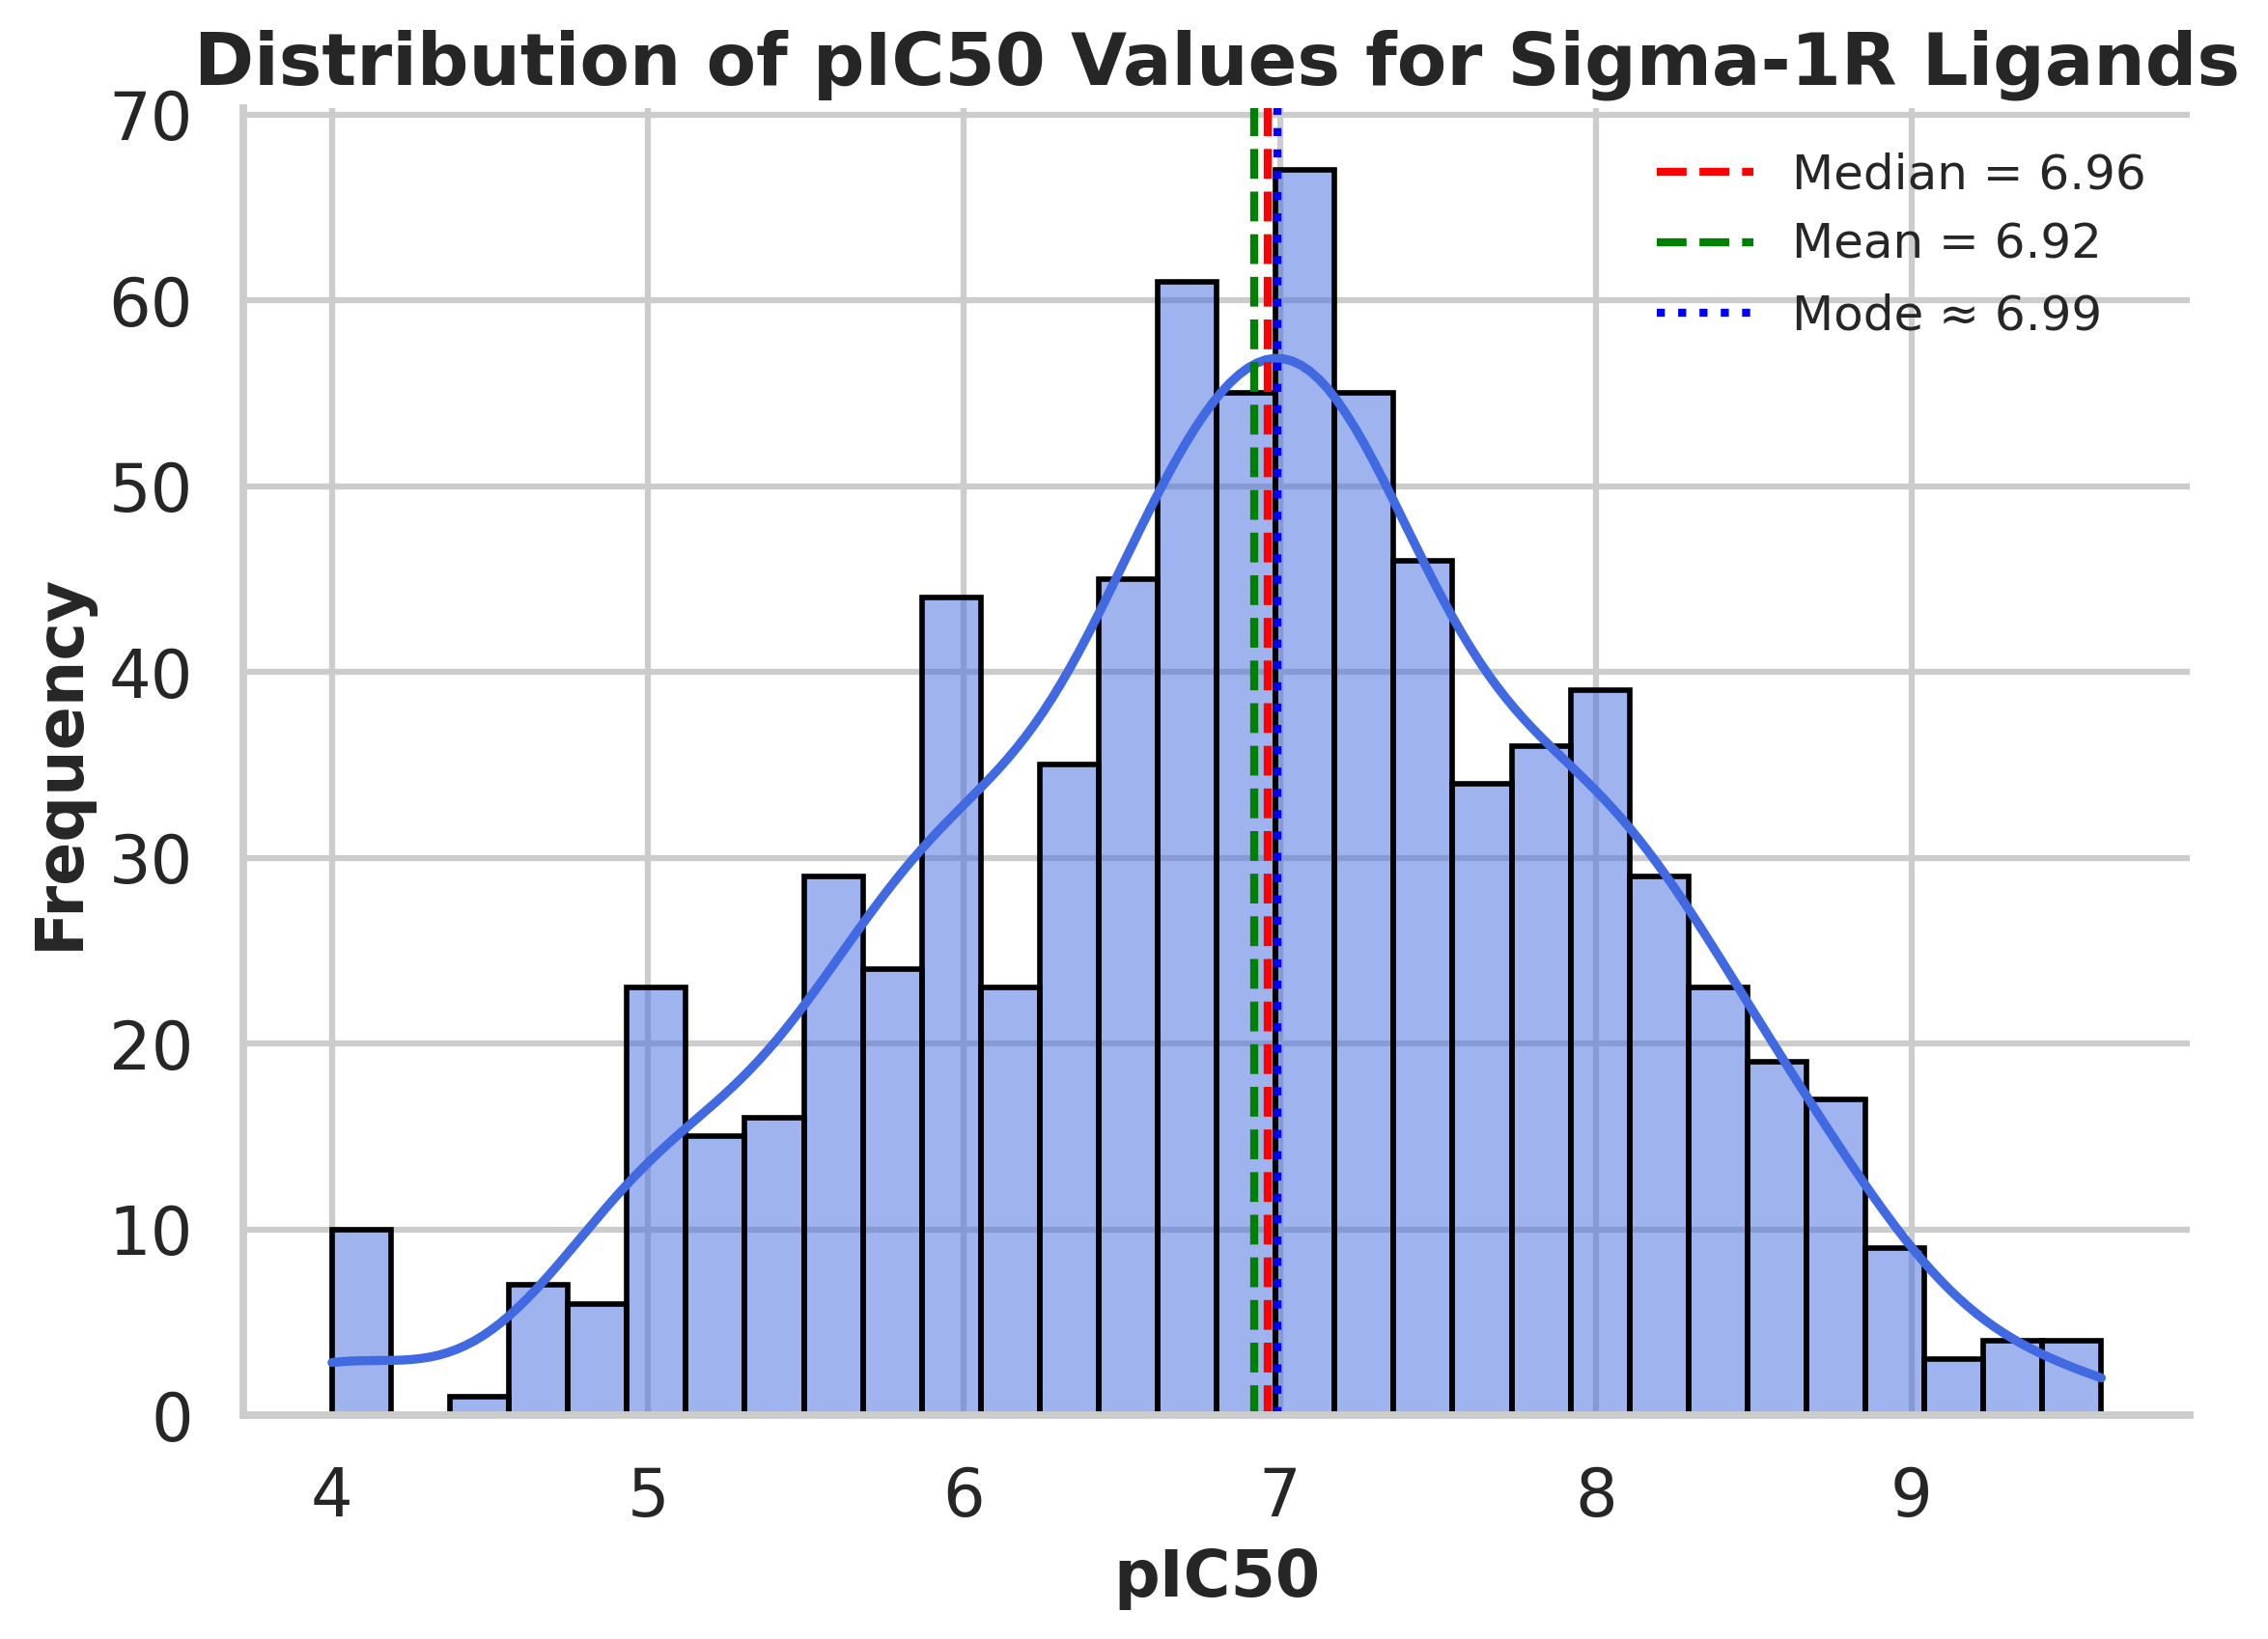

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Set style
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(8,6), dpi=300)

# Histogram + KDE overlay
sns.histplot(df["pIC50"], bins=30, kde=True, color="royalblue", edgecolor="black")

# Median and mean
plt.axvline(df["pIC50"].median(), color="red", linestyle="--", linewidth=2,
            label=f"Median = {df['pIC50'].median():.2f}")
plt.axvline(df["pIC50"].mean(), color="green", linestyle="--", linewidth=2,
            label=f"Mean = {df['pIC50'].mean():.2f}")

# --- Mode (KDE peak) ---
x_vals = np.linspace(df["pIC50"].min(), df["pIC50"].max(), 1000)
kde = gaussian_kde(df["pIC50"])
y_vals = kde(x_vals)
mode_x = x_vals[np.argmax(y_vals)]

plt.axvline(mode_x, color="blue", linestyle=":", linewidth=2,
            label=f"Mode ≈ {mode_x:.2f}")

# Labels and title
plt.xlabel("pIC50", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.title("Distribution of pIC50 Values for Sigma-1R Ligands", fontsize=18, fontweight="bold")

# Legend
plt.legend(fontsize=12, frameon=False)

# clean borders
sns.despine()

plt.tight_layout()
plt.savefig("../Results/Sigma1R_pIC50_distribution_with_mode.png", dpi=300)
plt.show()


**Split Data**

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

# -----------------------------
# Paths and Data Loading
# -----------------------------
data_dir = "../Data"
input_file = os.path.join(data_dir, "SIR_bioactivity_data_pIC50_03.csv")

# Load the curated dataset
df = pd.read_csv(input_file)
print(f"✅ Dataset loaded successfully: {df.shape[0]} compounds, {df.shape[1]} columns")

# -----------------------------
# Step 1: Bin the activity values (pIC50)
# -----------------------------
# We need bins so that stratified splitting works well
# (stratify = keep activity distribution balanced across Train/Val/Test)
try:
    discretizer = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile")
    y_binned = discretizer.fit_transform(df[["pIC50"]])
except ValueError:
    # fallback: use uniform bins if quantile bins fail
    discretizer = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="uniform")
    y_binned = discretizer.fit_transform(df[["pIC50"]])

# Merge very small bins (<2 samples) to avoid stratification errors
unique_bins, bin_counts = np.unique(y_binned, return_counts=True)
while np.any(bin_counts < 2):
    for bin_val in unique_bins[bin_counts < 2]:
        indices = np.where(y_binned == bin_val)[0]
        if bin_val > 0:
            y_binned[indices] = bin_val - 1  # merge with previous bin
        else:
            y_binned[indices] = bin_val + 1  # merge with next bin
    unique_bins, bin_counts = np.unique(y_binned, return_counts=True)

# -----------------------------
# Step 2: Train/Test/Validation Split
# -----------------------------
# Split into Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=y_binned,
    random_state=42
)

# Re-bin the temporary set for the next split
try:
    discretizer_temp = KBinsDiscretizer(n_bins=np.unique(y_binned).size, encode="ordinal", strategy="quantile")
    y_binned_temp = discretizer_temp.fit_transform(temp_df[["pIC50"]])
except ValueError:
    discretizer_temp = KBinsDiscretizer(n_bins=np.unique(y_binned).size, encode="ordinal", strategy="uniform")
    y_binned_temp = discretizer_temp.fit_transform(temp_df[["pIC50"]])

# Merge very small bins again if needed
unique_bins_temp, bin_counts_temp = np.unique(y_binned_temp, return_counts=True)
while np.any(bin_counts_temp < 2):
    for bin_val in unique_bins_temp[bin_counts_temp < 2]:
        indices = np.where(y_binned_temp == bin_val)[0]
        if bin_val > 0:
            y_binned_temp[indices] = bin_val - 1
        else:
            y_binned_temp[indices] = bin_val + 1
    unique_bins_temp, bin_counts_temp = np.unique(y_binned_temp, return_counts=True)

# Final split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # half of 30% = 15%
    stratify=y_binned_temp,
    random_state=42
)

# -----------------------------
# Step 3: Save Outputs
# -----------------------------
train_file = os.path.join(data_dir, "sigma1r_train.csv")
val_file   = os.path.join(data_dir, "sigma1r_val.csv")
test_file  = os.path.join(data_dir, "sigma1r_test.csv")

train_df.to_csv(train_file, index=False)
val_df.to_csv(val_file, index=False)
test_df.to_csv(test_file, index=False)

print(f"✅ Data successfully split and saved:")
print(f"   • Train: {train_df.shape[0]} compounds → {train_file}")
print(f"   • Val:   {val_df.shape[0]} compounds → {val_file}")
print(f"   • Test:  {test_df.shape[0]} compounds → {test_file}")


✅ Dataset loaded successfully: 779 compounds, 5 columns
✅ Data successfully split and saved:
   • Train: 545 compounds → ../Data/sigma1r_train.csv
   • Val:   117 compounds → ../Data/sigma1r_val.csv
   • Test:  117 compounds → ../Data/sigma1r_test.csv


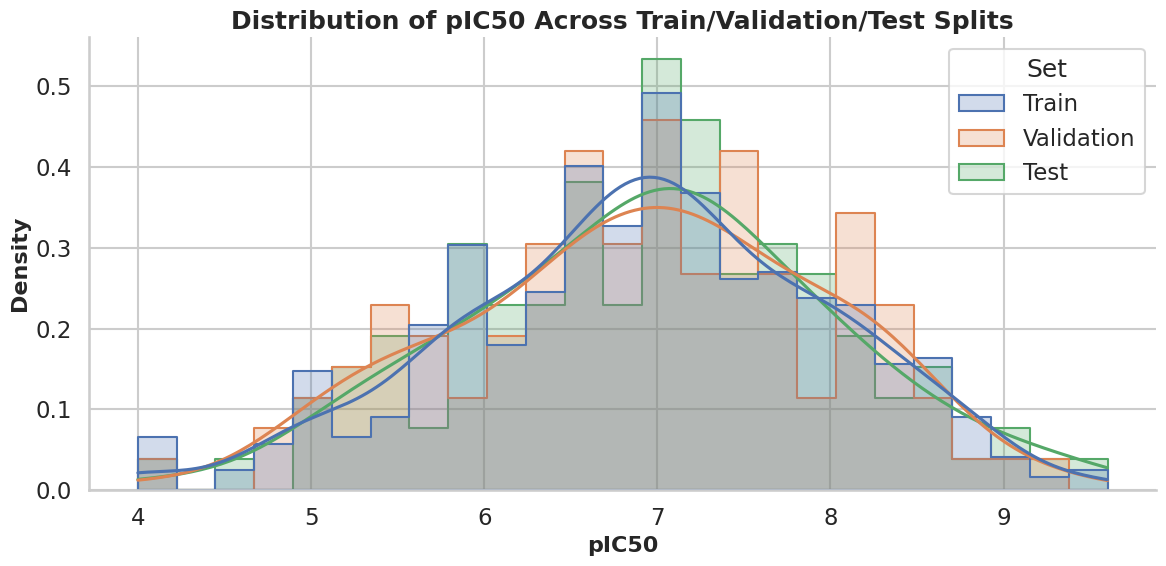

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the split datasets
train_df = pd.read_csv("../Data/sigma1r_train.csv")
val_df   = pd.read_csv("../Data/sigma1r_val.csv")
test_df  = pd.read_csv("../Data/sigma1r_test.csv")

# Combine for plotting
train_df["Set"] = "Train"
val_df["Set"] = "Validation"
test_df["Set"] = "Test"

df_all = pd.concat([train_df, val_df, test_df])

# -----------------------------
# Plot distributions
# -----------------------------
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12,6))
sns.histplot(
    data=df_all,
    x="pIC50",
    hue="Set",
    bins=25,
    kde=True,
    element="step",  # outline style (less cluttered)
    stat="density",  # normalize for better comparison
    common_norm=False
)

# Labels and title
plt.xlabel("pIC50", fontsize=16, fontweight="bold")
plt.ylabel("Density", fontsize=16, fontweight="bold")
plt.title("Distribution of pIC50 Across Train/Validation/Test Splits", fontsize=18, fontweight="bold")

# Remove top/right borders
sns.despine()

plt.tight_layout()
plt.savefig("../Results/Sigma1R_pIC50_distribution_train_val_test.png", dpi=300)
plt.show()
